# DESI / MaNGA Halpha Map (Fixed Object)

This notebook reproduces the same chunked map-generation procedure from `manga_tests.ipynb` for:
- MaNGA: `8244-12705`
- DESI TARGETID: `39633270597487792`

Final output shows three panels side-by-side:
1. DESI RGB image
2. Predicted Halpha map from the model (same grid/loop method)
3. Actual MaNGA Halpha map

In [5]:
import sys
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from astropy.io import fits
from torch.utils.data import DataLoader
from scipy.optimize import curve_fit

sys.path.append('..')
from utils.DataProcessing import MultimodalDataset
from utils.AstroImageFunctions import make_rgb
from train.FixedCLSTokenTrain import MaskedAutoencoderViT

class PairExtractor:
    def __init__(self,
        desi_zarr_path='/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr',
        desi_parquet_path='/pscratch/sd/p/pzehao/iron/desi_zcat_maglim_19_5.parquet',
        maps_cache_dir='/pscratch/sd/p/pzehao/MyQuota/manga_maps',
        map_daptype='HYB10-MILESHC-MASTARHC2',
    ):
        self.desi_zarr_path = Path(desi_zarr_path)
        self.desi_parquet_path = Path(desi_parquet_path)
        self.maps_cache_dir = Path(maps_cache_dir)
        self.map_daptype = map_daptype

        import zarr
        self.z = zarr.open(str(self.desi_zarr_path), mode='r')
        self.wave = np.asarray(self.z['WAVE'][:], dtype=np.float32)
        self._desi = None

    def desi_table(self):
        if self._desi is None:
            cols = ['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'MEAN_FIBER_RA', 'MEAN_FIBER_DEC', 'Z']
            t = pd.read_parquet(self.desi_parquet_path, columns=cols).copy()
            t['TARGETID'] = t['TARGETID'].astype(np.int64)
            self._desi = t
        return self._desi

    def get_loader(self, desi_index):
        ds = MultimodalDataset(str(self.desi_zarr_path), start=int(desi_index), end=int(desi_index)+1, augment=False, max_shift=0)
        return DataLoader(ds, batch_size=1, shuffle=False)

    def _maps_path(self, plateifu):
        plate, ifu = plateifu.split('-')
        self.maps_cache_dir.mkdir(parents=True, exist_ok=True)
        p = self.maps_cache_dir / f'manga-{plateifu}-MAPS-{self.map_daptype}.fits.gz'
        if not p.exists():
            u = (
                f'https://data.sdss.org/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/'
                f'{self.map_daptype}/{plate}/{ifu}/manga-{plateifu}-MAPS-{self.map_daptype}.fits.gz'
            )
            urlretrieve(u, p)
        return p

    @staticmethod
    def _ch(header, token):
        token = token.lower()
        for k, v in header.items():
            if isinstance(k, str) and k.startswith('C') and isinstance(v, str) and token in v.lower():
                return int(k[1:]) - 1
        raise KeyError(token)

    @staticmethod
    def _masked(h, ext, idx=None):
        d = np.asarray(h[ext].data if idx is None else h[ext].data[idx], dtype=np.float32)
        bad = np.zeros_like(d, dtype=bool)
        me = f'{ext}_MASK'
        ie = f'{ext}_IVAR'
        if me in h:
            m = np.asarray(h[me].data if idx is None else h[me].data[idx])
            bad |= (m != 0)
        if ie in h:
            iv = np.asarray(h[ie].data if idx is None else h[ie].data[idx], dtype=np.float32)
            bad |= (~np.isfinite(iv)) | (iv <= 0)
        d[bad] = np.nan
        return d

    def get_maps(self, plateifu):
        p = self._maps_path(plateifu)
        with fits.open(p) as h:
            i_ha = self._ch(h['EMLINE_GFLUX'].header, 'Ha-6564')
            return {
                'ha_flux': self._masked(h, 'EMLINE_GFLUX', i_ha),
            }

C_KMS = 299792.458
HA_REST = 6564.61
NII6548_REST = 6549.86
NII6583_REST = 6585.27
NII_RATIO_6583_TO_6548 = 3.06
DN4000_BLUE_MIN = 3850.0
DN4000_BLUE_MAX = 3950.0
DN4000_RED_MIN = 4000.0
DN4000_RED_MAX = 4100.0

In [6]:
import os
from concurrent.futures import ProcessPoolExecutor

def _gauss_from_flux(lam, flux_int, mu, sigma):
    amp = flux_int / (np.sqrt(2.0 * np.pi) * sigma)
    return amp * np.exp(-0.5 * ((lam - mu) / sigma) ** 2)

def _halpha_single_dap_like(wave_obs, flux_obs, z_obj, ivar_obs=None):
    wave_obs = np.asarray(wave_obs, dtype=np.float64)
    flux_obs = np.asarray(flux_obs, dtype=np.float64)

    if ivar_obs is not None:
        ivar_obs = np.asarray(ivar_obs, dtype=np.float64)

    lam0 = HA_REST * (1.0 + z_obj)
    win_half = 45.0 * (1.0 + z_obj)
    m = (
        np.isfinite(wave_obs)
        & np.isfinite(flux_obs)
        & (wave_obs >= lam0 - win_half)
        & (wave_obs <= lam0 + win_half)
    )
    if ivar_obs is not None:
        m &= np.isfinite(ivar_obs) & (ivar_obs > 0)

    w = wave_obs[m]
    f = flux_obs[m]
    if len(w) < 30:
        raise RuntimeError('Not enough valid pixels in Halpha window for fitting')

    side = ((w < lam0 - 12.0) | (w > lam0 + 12.0))
    c0 = float(np.nanmedian(f[side])) if np.any(side) else float(np.nanmedian(f))
    c1 = 0.0
    cont_guess = c0 + c1 * (w - lam0)
    pos = np.clip(f - cont_guess, 0.0, None)
    f_ha0 = max(float(np.trapz(pos, w)), 1e-3)
    f_nii6583_0 = 0.3 * f_ha0

    def model(lam, cont0, cont1, f_ha, f_nii6583, dv_kms, sigma_kms):
        z_shift = (1.0 + z_obj) * (1.0 + dv_kms / C_KMS)
        mu_ha = HA_REST * z_shift
        mu_6548 = NII6548_REST * z_shift
        mu_6583 = NII6583_REST * z_shift

        sigma_ha = (sigma_kms / C_KMS) * mu_ha
        sigma_6548 = (sigma_kms / C_KMS) * mu_6548
        sigma_6583 = (sigma_kms / C_KMS) * mu_6583

        f_nii6548 = f_nii6583 / NII_RATIO_6583_TO_6548

        y = cont0 + cont1 * (lam - lam0)
        y += _gauss_from_flux(lam, f_ha, mu_ha, sigma_ha)
        y += _gauss_from_flux(lam, f_nii6548, mu_6548, sigma_6548)
        y += _gauss_from_flux(lam, f_nii6583, mu_6583, sigma_6583)
        return y

    p0 = [c0, c1, f_ha0, f_nii6583_0, 0.0, 120.0]
    lower = [-np.inf, -np.inf, 0.0, 0.0, -400.0, 20.0]
    upper = [np.inf, np.inf, np.inf, np.inf, 400.0, 500.0]

    sigma_y = None
    if ivar_obs is not None:
        sigma_y = 1.0 / np.sqrt(np.clip(ivar_obs[m], 1e-20, None))

    popt, _ = curve_fit(model, w, f, p0=p0, bounds=(lower, upper), sigma=sigma_y, absolute_sigma=(sigma_y is not None), maxfev=20000)
    cont0, cont1, f_ha, f_nii6583, dv_kms, sigma_kms = popt

    blue_min_obs = DN4000_BLUE_MIN * (1.0 + z_obj)
    blue_max_obs = DN4000_BLUE_MAX * (1.0 + z_obj)
    red_min_obs = DN4000_RED_MIN * (1.0 + z_obj)
    red_max_obs = DN4000_RED_MAX * (1.0 + z_obj)

    m_blue = (wave_obs >= blue_min_obs) & (wave_obs <= blue_max_obs) & np.isfinite(flux_obs)
    m_red = (wave_obs >= red_min_obs) & (wave_obs <= red_max_obs) & np.isfinite(flux_obs)
    if np.any(m_blue) and np.any(m_red):
        flux_blue = np.mean(flux_obs[m_blue])
        flux_red = np.mean(flux_obs[m_red])
        dn4000 = float(flux_red / flux_blue) if flux_blue > 0 else np.nan
    else:
        dn4000 = np.nan

    return {
        'halpha_flux': float(f_ha),
        'nii6583_flux': float(f_nii6583),
        'dv_kms': float(dv_kms),
        'sigma_kms': float(sigma_kms),
        'dn4000': dn4000,
    }

def _halpha_worker(args):
    wave_obs, spec_i, z_i = args
    return _halpha_single_dap_like(wave_obs, spec_i, z_i)

def extract_halpha_kinematics(spectra, wave_obs, redshifts, left_patches=None, patch_size=None, return_dataframe=False, n_workers=1):
    wave_obs = np.asarray(wave_obs, dtype=np.float64)
    L = len(wave_obs)
    spec_arr = np.asarray(spectra)
    if spec_arr.ndim == 1:
        spec_arr = spec_arr[None, :]

    z_arr = np.asarray(redshifts, dtype=np.float64)
    if z_arr.ndim == 0:
        z_arr = np.full(spec_arr.shape[0], float(z_arr), dtype=np.float64)

    if spec_arr.shape[1] != L:
        if left_patches is None or patch_size is None:
            raise ValueError('Provide left_patches and patch_size when spectra length != wave length')
        offset = int(left_patches) * int(patch_size)
        spec_arr = spec_arr[:, offset:offset + L]

    if int(n_workers) <= 1 or spec_arr.shape[0] == 1:
        rows = [_halpha_single_dap_like(wave_obs, spec_arr[i], z_arr[i]) for i in range(spec_arr.shape[0])]
    else:
        jobs = [(wave_obs, spec_arr[i], float(z_arr[i])) for i in range(spec_arr.shape[0])]
        with ProcessPoolExecutor(max_workers=int(n_workers)) as ex:
            rows = list(ex.map(_halpha_worker, jobs))

    if return_dataframe:
        return pd.DataFrame(rows)
    return rows

In [45]:
# Fixed object IDs
PLATEIFU = '8244-12705'
TARGETID = 39633270597487792

# Model checkpoint used in manga_tests workflow
CKPT_PATH = '/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=066-val_loss=-1.5122.ckpt'

extractor = PairExtractor()
desi_tab = extractor.desi_table()

hit = desi_tab.loc[desi_tab['TARGETID'] == np.int64(TARGETID)]
if len(hit) == 0:
    raise KeyError(f'TARGETID {TARGETID} not found in DESI table')
DESI_INDEX = int(hit.index[0])
row = desi_tab.iloc[DESI_INDEX]

# Optional safety check against your explicit pairing list
matches = pd.read_csv('/pscratch/sd/p/pzehao/desi_manga_matches.csv')
m = matches[(matches['TARGETID'] == TARGETID) & (matches['plateifu'].astype(str) == PLATEIFU)]
if len(m) == 0:
    print('Warning: explicit pair not found in desi_manga_matches.csv, continuing with user-provided IDs.')

prob = 0.7 / 15
model = MaskedAutoencoderViT(
    spec_dim=7781,
    max_epochs=600,
    warmup_epoch=5,
    mask_ratio=0.75,
    embed_dim=256,
    merged_depth=4,
    merged_num_heads=8,
    s_depth=4,
    e_depth=4,
    s_num_heads=8,
    e_num_heads=8,
    decoder_embed_dim=512,
    decoder_depth=8,
    decoder_num_heads=16,
    decoder_MLP_coefficient=1,
    patch_scheme={
        'patch_sizes': [1, 1, 2, 4, 8, 16, 32, 64, 128, 64, 32, 16, 8, 4, 2, 1],
        'mask_ratios': [1, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.2, 0.1, 0.0],
        'probs': [0.3, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob],
    },
)
checkpoint = torch.load(CKPT_PATH, map_location='cpu')
model.load_state_dict(checkpoint['state_dict'], strict=False)
model.eval()

loader = extractor.get_loader(DESI_INDEX)
batch = next(iter(loader))

target_ra = float(row['TARGET_RA'])
target_dec = float(row['TARGET_DEC'])
img_6ch = batch[4][0].detach().cpu().numpy()
desi_rgb = make_rgb(img_6ch[[0, 1, 3]], 'ls_grz')

print('Loaded TARGETID:', TARGETID)
print('DESI index:', DESI_INDEX)
print('Using MaNGA plateifu:', PLATEIFU)

/tmp/ipykernel_1519902/3484566388.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CKPT_PATH, map_location='cpu')


Loaded TARGETID: 39633270597487792
DESI index: 4156314
Using MaNGA plateifu: 8244-12705


In [17]:
from utils.DataProcessing import (
    generate_rest_indices,
    get_extreme_mask,
    get_kernel,
    safe_collate,
    smooth_data,
    MultimodalDataset,
    CreateMultimodalDataLoadersIter,
)
def visualize(model, spec: torch.Tensor, error: torch.Tensor, spec_pred: torch.Tensor, 
                error_pred: torch.Tensor, img: torch.Tensor, pred_img: torch.Tensor, error_img: torch.Tensor, mask_spec: torch.Tensor, mask_img: torch.Tensor, xy_pix: torch.Tensor,
                i: int = 0, ylim: int = 25, nsmooth: int = 3):
    kernel = get_kernel(nsmooth)

    # Extract relevant sample
    target = spec[i].detach().cpu().numpy()
    target_error = error[i].detach().cpu().numpy()
    pred_mean = spec_pred[i].detach().cpu().numpy()
    pred_sigma = np.exp(error_pred[i].detach().cpu().numpy())
    patch_mask_spec = mask_spec[i].detach().cpu()
    patch_mask_img = mask_img[i].detach().cpu()

    # Smooth signal and error
    target_smooth = smooth_data(target, kernel)
    target_error_smooth = smooth_data(target_error, kernel)

    # Compute intervals
    pred_upper = pred_mean + pred_sigma
    pred_lower = pred_mean - pred_sigma
    data_upper = target_smooth + target_error_smooth
    data_lower = target_smooth - target_error_smooth

    # Plot masked reconstruction
    fig, ax = plt.subplots(figsize=(10, 3))
    offset = model.left_patches * model.patch_size
    x_range = np.arange(offset, offset + len(target_smooth))
    ax.plot(x_range, target_smooth, label="Target (smoothed)", color="orange", linewidth=1)
    ax.fill_between(x_range, data_lower, data_upper, color="orange", alpha=0.3, label="±σ data (smoothed)")
    ax.plot(pred_mean, label="Prediction", color="blue")
    ax.fill_between(range(len(pred_mean)), pred_lower, pred_upper, color="blue", alpha=0.3, label="±σ predicted")
    patch_len = model.patch_size
    for j, masked in enumerate(patch_mask_spec):
        if masked:
            start = offset + j * patch_len
            end = offset + (j + 1) * patch_len
            ax.axvspan(start, end, color='red', alpha=0.05)
    ax.set_title(f"Patch Size = {model.patch_size*model.chunk_size}, {model.mask_ratio} (Val Sample {i})")
    ax.set_xlabel("Pixel index")
    ax.set_ylabel("Value")
    ax.set_ylim(-0, ylim)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    N = model.patch_embedimg.num_patches
    p = pred_img[i].view(model.num_img_channels, N, model.img_patch, model.img_patch)
    p = p.view(model.num_img_channels, 128//model.img_patch, 128//model.img_patch, model.img_patch, model.img_patch)                  # (C, 8, 8, 16, 16)
    pred_img_formatted = p.permute(0,1,3,2,4).reshape(model.num_img_channels, 128, 128).detach().cpu().numpy()
    
    img_formatted = img[i].detach().cpu().numpy() 
    pred_rgb = make_rgb(pred_img_formatted[[0, 1, 3]], "ls_grz") 
    img_rgb = make_rgb(img_formatted[[0, 1, 3]], "ls_grz") 
    
    # mask: (384,) -> (6,64) -> (6,8,8)
    # m = patch_mask_img.float().view(6, 64).view(6, 8, 8)

    # # opacity per spatial patch = fraction of channels masked
    # alpha_patch = m.mean(dim=0).cpu().numpy()                 # (8,8)
    # alpha128 = np.kron(alpha_patch, np.ones((16, 16)))        # (128,128)
    xy_pix_val = xy_pix[i].detach().cpu().numpy()

    fig2, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(img_rgb)
    axs[0].set_title("True")

    ticks = np.arange(0, 129, 16)
    axs[0].set_xticks(ticks)
    axs[0].set_yticks(ticks)

    axs[0].set_xticklabels(ticks - 64)
    axs[0].set_yticklabels(64 - ticks)

    axs[0].grid(True, color='white', alpha=0.7, linewidth=0.5)

    axs[0].scatter(
        xy_pix_val[0] + 64,
        64 - xy_pix_val[1],
        c='red', s=50, marker='x'
    )

    axs[1].imshow(pred_rgb)
    # axs[1].imshow(alpha128, cmap="Reds", alpha=alpha128)
    axs[1].set_title("Masked Reconstruction")
    axs[1].axis("off")

    plt.tight_layout()
    
    plt.show()
    plt.close(fig)
    plt.close(fig2)

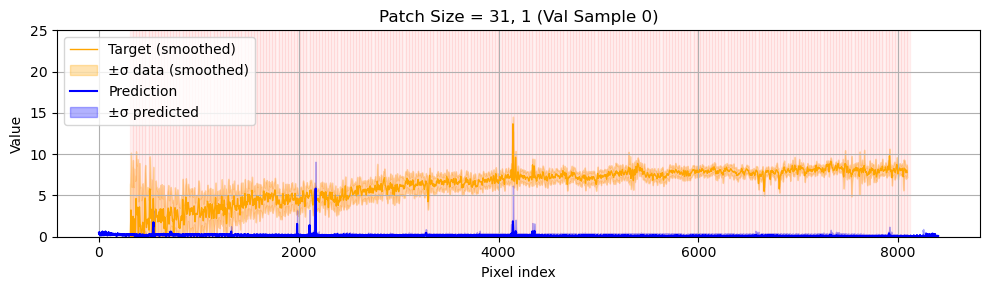

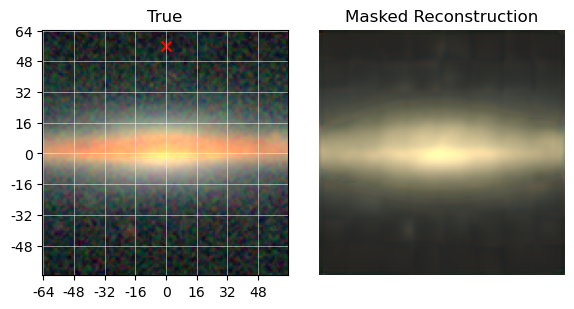

In [47]:
device = next(model.parameters()).device
model.eval()

x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
spec   = spec.to(device)
weig   = weig.to(device)
error  = error.to(device)
img    = img.to(device)
img_w  = img_w.to(device)
img_e  = img_e.to(device)
z      = z.to(device)
xy_pix = xy_pix.to(device)

model.mask_ratio = 1
model.mask_ratio_img = 0.0
# z[0] = 0.2429
xy_pix[0] = torch.tensor([0, 56])
spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = model.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)

token_mask = token_mask.unsqueeze(0).expand(spec.size(0), -1)
mask_spec = token_mask[:, :-model.num_patchesimg].long()
mask_img = token_mask[:, -model.num_patchesimg:].long()
visualize(model, spec, error, spec_pred, error_pred, img, pred_img, error_img, mask_spec, mask_img, xy_pix)

In [28]:
device = next(model.parameters()).device
model.eval()

x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch

# move inputs to GPU
spec   = spec.to(device)
weig   = weig.to(device)
error  = error.to(device)
img    = img.to(device)
img_w  = img_w.to(device)
img_e  = img_e.to(device)
z      = z.to(device)
xy_pix = xy_pix.to(device)

wave_obs = np.asarray(extractor.wave, dtype=np.float64)

# ---------------------------------------------------------
# choose finer sampling here
x_min, x_max, dx = -63, 63, 2
y_min, y_max, dy = -63, 63, 2
chunk_size = 64   # tune this: 32, 64, 128, ...
# ---------------------------------------------------------

# keep EXACT same ordering:
# outer loop: top -> bottom in y
# inner loop: left -> right in x
xs = torch.arange(x_min, x_max + 1, dx, device=device, dtype=xy_pix.dtype)
ys = torch.arange(y_max, y_min - 1, -dy, device=device, dtype=xy_pix.dtype)

nx = xs.numel()
ny = ys.numel()

coords = []
for i in range(ny):
    for j in range(nx):
        coords.append([xs[j], ys[i]])

coords = torch.stack(
    [torch.as_tensor(c, device=device, dtype=xy_pix.dtype) for c in coords],
    dim=0
)  # (N, 2)

N = coords.shape[0]

# outputs in flattened row-major order matching coords
halphas_flat       = np.zeros(N, dtype=np.float64)
nii6583_fluxs_flat = np.zeros(N, dtype=np.float64)
dv_kmses_flat      = np.zeros(N, dtype=np.float64)
dn4000s_flat       = np.zeros(N, dtype=np.float64)

with torch.no_grad():
    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)
        bsz = end - start

        xy_pix_chunk = coords[start:end]              # (bsz, 2)

        # repeat single example only for this chunk
        spec_b   = spec.repeat(bsz, 1)
        weig_b   = weig.repeat(bsz, 1)
        error_b  = error.repeat(bsz, 1)
        img_b    = img.repeat(bsz, 1, 1, 1)
        img_w_b  = img_w.repeat(bsz, 1, 1, 1)
        img_e_b  = img_e.repeat(bsz, 1, 1, 1)
        z_b      = z.repeat(bsz)

        spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = model.forward(
            spec_b, weig_b, error_b, img_b, img_w_b, img_e_b, z_b, xy_pix_chunk
        )

        pred_np = spec_pred.detach().cpu().numpy()
        z_np    = z_b.detach().cpu().numpy()

        values_all = extract_halpha_kinematics(
            spectra=pred_np,
            wave_obs=wave_obs,
            redshifts=z_np,
            left_patches=model.left_patches,
            patch_size=model.patch_size,
            return_dataframe=False,
        )

        for k, values in enumerate(values_all):
            idx = start + k
            halphas_flat[idx]       = values['halpha_flux']
            nii6583_fluxs_flat[idx] = values['nii6583_flux']
            dv_kmses_flat[idx]      = values['dv_kms']
            dn4000s_flat[idx]       = values['dn4000']

# reshape back to grid with SAME ordering as original loop
halphas       = halphas_flat.reshape(ny, nx)
nii6583_fluxs = nii6583_fluxs_flat.reshape(ny, nx)
dv_kmses      = dv_kmses_flat.reshape(ny, nx)
dn4000s       = dn4000s_flat.reshape(ny, nx)

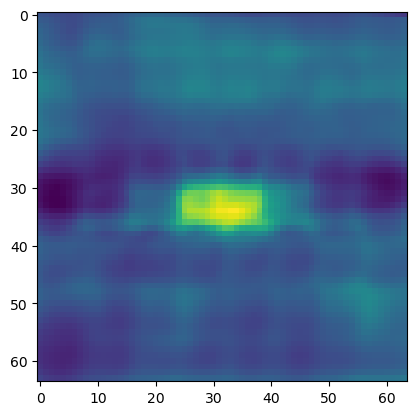

In [29]:
plt.imshow(halphas)

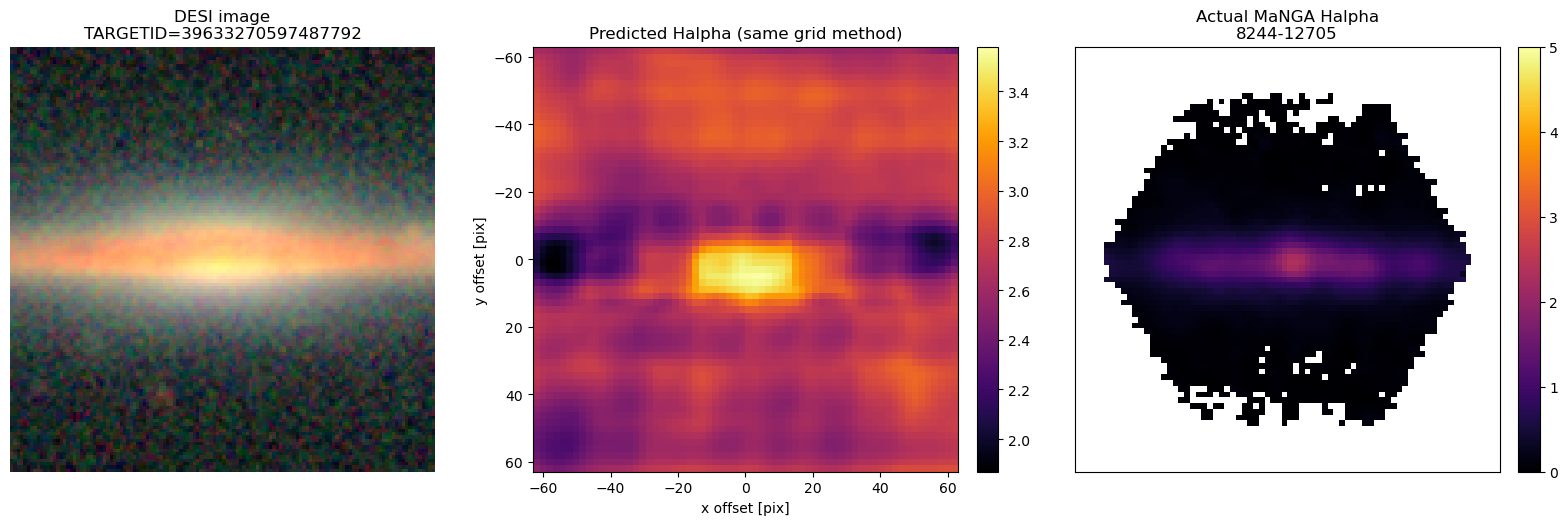

In [44]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].imshow(desi_rgb)
ax[0].set_title(f'DESI image\nTARGETID={TARGETID}')
ax[0].axis('off')

im1 = ax[1].imshow(np.log(halphas), origin='lower', extent=(x_min, x_max, y_min, y_max), cmap='inferno')
ax[1].invert_yaxis()
ax[1].set_title('Predicted Halpha (same grid method)')
ax[1].set_xlabel('x offset [pix]')
ax[1].set_ylabel('y offset [pix]')
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(ha_manga, origin='lower', cmap='inferno', vmin=0, vmax=5)
ax[2].set_title(f'Actual MaNGA Halpha\n{PLATEIFU}')
ax[2].set_xticks([])
ax[2].set_yticks([])
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()